# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [6]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Завантажуємо дані
df = pd.read_csv('/Users/olesialev/Downloads/data:/statistical_hypothesis/House_Rent_Dataset.csv', sep=None, engine='python')

# Перше знайомство з даними
df.shape

(4746, 12)

In [4]:
df.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [7]:
# 1.Аналіз пропущених значень
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [9]:
# 2. Базова статистика
display(df.describe())

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


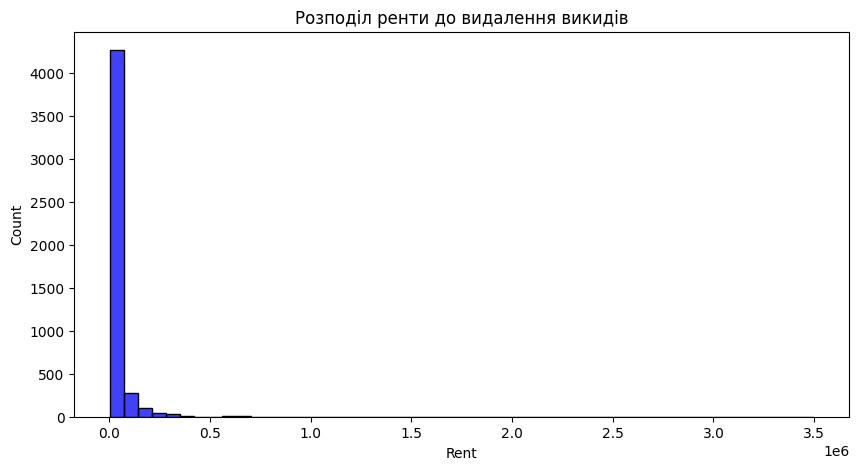

In [11]:
# 3. Аналіз цільової змінної (до видалення викидів)
plt.figure(figsize=(10, 5))
sns.histplot(df['Rent'], bins=50, color='blue')
plt.title('Розподіл ренти до видалення викидів')
plt.show()

In [12]:
# 4. Робота з викидами 
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Межі для викидів: від -24500.0 до 67500.0
Видалено записів: 520


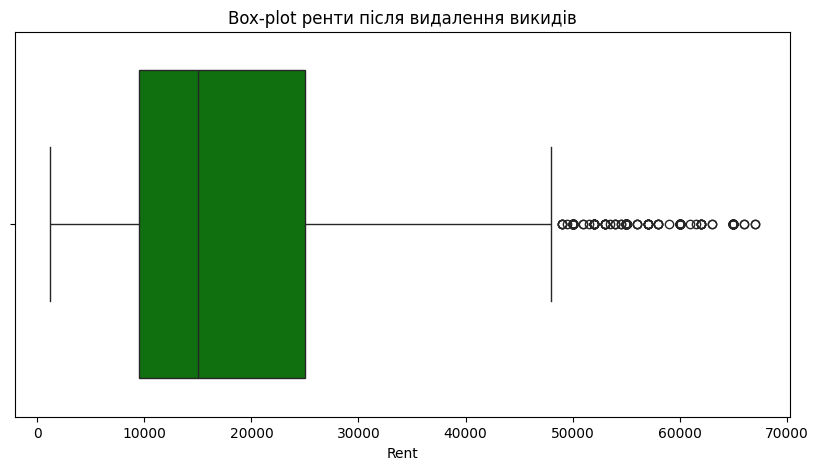

In [14]:
# Фільтруємо дані
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)].copy()

print(f"Межі для викидів: від {lower_bound} до {upper_bound}")
print(f"Видалено записів: {len(df) - len(df_clean)}")

# Візуалізація після очищення
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['Rent'], color='green')
plt.title('Box-plot ренти після видалення викидів')
plt.show()

In [16]:
# 5. Аналіз категоріальних змінних
categorical_cols = df_clean.select_dtypes(include=['object']).columns
print("Кількість унікальних значень у категоріальних колонках:")
for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()}")

Кількість унікальних значень у категоріальних колонках:
Posted On: 80
Floor: 340
Area Type: 3
Area Locality: 1997
City: 6
Furnishing Status: 3
Tenant Preferred: 3
Point of Contact: 3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [18]:
# 1. Обчислення матриці кореляцій
corr_matrix = df_clean.select_dtypes(include=['int64', 'float64']).corr()
print("Матриця кореляцій:")
display(corr_matrix)

Матриця кореляцій:


,BHK,Rent,Size,Bathroom
BHK,1.000000,0.401268,0.698453,0.747918
Rent,0.401268,1.000000,0.393605,0.506528
Size,0.698453,0.393605,1.000000,0.680607
Bathroom,0.747918,0.506528,0.680607,1.000000


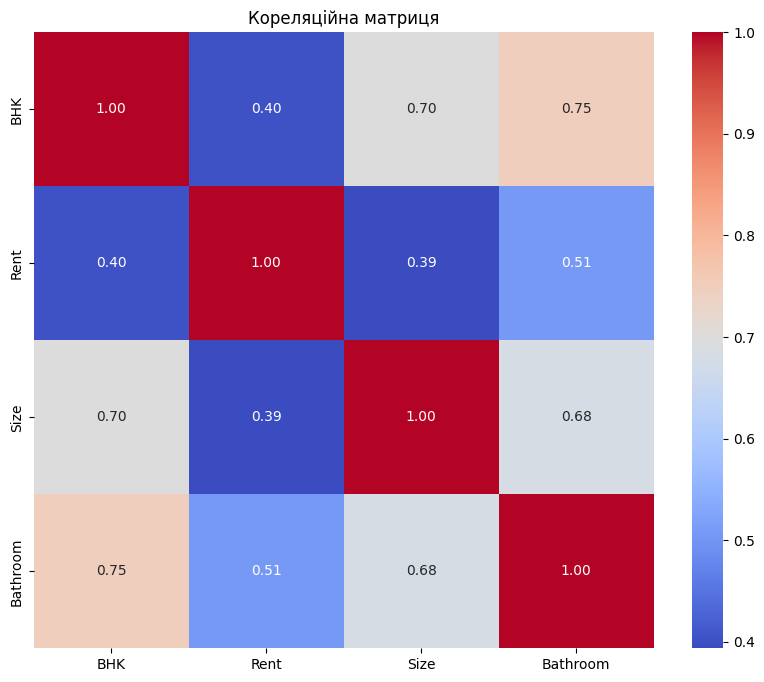

In [19]:
# 2. Візуалізація heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Кореляційна матриця')
plt.show()

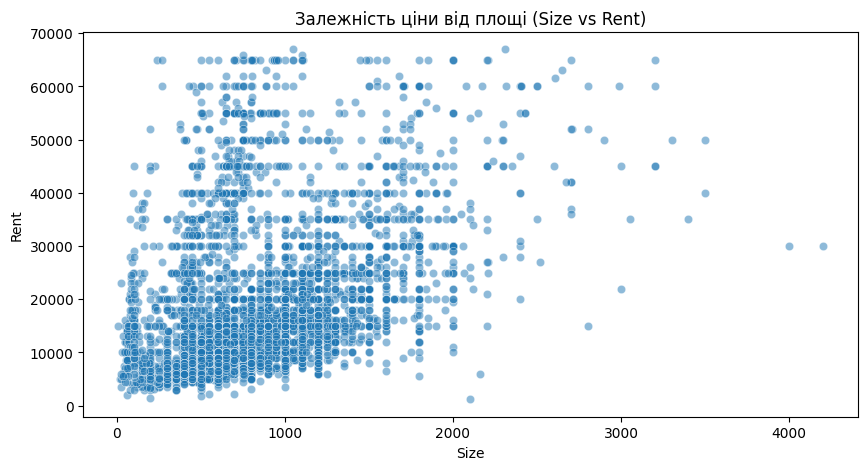

In [20]:
# 3. Scatter plot: Size vs Rent
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='Size', y='Rent', alpha=0.5)
plt.title('Залежність ціни від площі (Size vs Rent)')
plt.show()

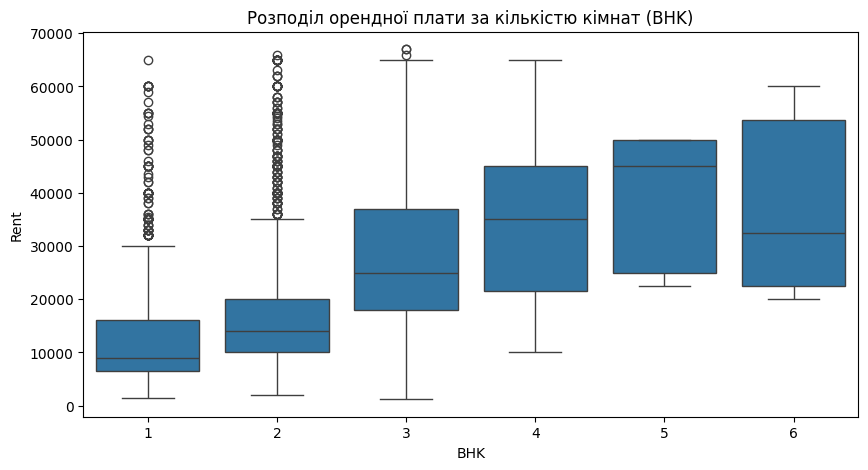

In [21]:
# 4. Boxplot: BHK vs Rent
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='BHK', y='Rent')
plt.title('Розподіл орендної плати за кількістю кімнат (BHK)')
plt.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [22]:
# Видаляємо непотрібні колонки
cols_to_drop = ['Posted On', 'Area Locality', 'Floor'] 
df_model = df_clean.drop(columns=cols_to_drop)

# One-Hot Encoding для вибраних категоріальних ознак
# Обираємо ті, що мають небагато значень
cat_cols = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

In [23]:
df_model['BHK_per_Bathroom'] = df_model['BHK'] / (df_model['Bathroom'] + 1) 

In [24]:
X = df_model.drop(columns=['Rent'])
y = df_model['Rent']

In [26]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 8.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Розділення на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизація
scaler = StandardScaler()
num_cols = ['BHK', 'Size', 'Bathroom', 'BHK_per_Bathroom']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [30]:
print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір навчальної вибірки: (3380, 17)
Розмір тестової вибірки: (846, 17)


In [31]:
from sklearn.linear_model import LinearRegression

# 1. Створення моделі
model = LinearRegression()

# 2. Навчання моделі на навчальних даних
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
# 3. Отримання коефіцієнтів
coefficients = pd.DataFrame({'Feature': X.columns, 'Weight': model.coef_})
# Сортуємо за модулем ваги, щоб побачити справжній вплив 
coefficients['Abs_Weight'] = coefficients['Weight'].abs()
coefficients = coefficients.sort_values(by='Abs_Weight', ascending=False)

print("Коефіцієнти моделі (ваги):")
print(coefficients[['Feature', 'Weight']])

Коефіцієнти моделі (ваги):
                              Feature        Weight
9                         City_Mumbai  18656.535821
16                   BHK_per_Bathroom -10154.732322
15     Point of Contact_Contact Owner  -8689.727554
0                                 BHK   7440.437404
14   Point of Contact_Contact Builder  -6152.334460
11      Furnishing Status_Unfurnished  -4559.864298
10   Furnishing Status_Semi-Furnished  -3421.164581
8                        City_Kolkata  -3057.026095
7                      City_Hyderabad  -2375.265939
4                Area Type_Super Area  -2253.663892
13            Tenant Preferred_Family  -2227.868937
3               Area Type_Carpet Area  -2006.115150
6                          City_Delhi   1939.611809
5                        City_Chennai  -1151.228667
12  Tenant Preferred_Bachelors/Family   -656.959181
2                            Bathroom   -110.696054
1                                Size      7.837292


In [33]:
# 4. Прогнози
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Виведення 2 ознак, які найбільше впливають
print("Дві ознаки, що найбільше впливають на прогноз:")
print(coefficients.head(2)['Feature'].values)

Дві ознаки, що найбільше впливають на прогноз:
['City_Mumbai' 'BHK_per_Bathroom']


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Функція для розрахунку RMSE
def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- Метрики для {name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

get_metrics(y_train, y_train_pred, "Training Set")
get_metrics(y_test, y_test_pred, "Test Set")

--- Метрики для Training Set ---
MAE: 5497.01
RMSE: 7683.93
R²: 0.6907
--- Метрики для Test Set ---
MAE: 5467.95
RMSE: 7697.56
R²: 0.6910


 2.Порівняння метрик та якість моделі: Оскільки значення метрик на тренувальній та тестовій вибірках практично ідентичні, модель демонструє високу стабільність і здатність до узагальнення.

3. Ознак перенавчання чи недонавчання немає адже модель не показує критичного розриву між якістю на тренуванні та тесті, а досягнутий рівень $R^2 = 0.69$ свідчить про адекватну здатність моделі вловлювати закономірності в даних без надмірного підлаштування під них.

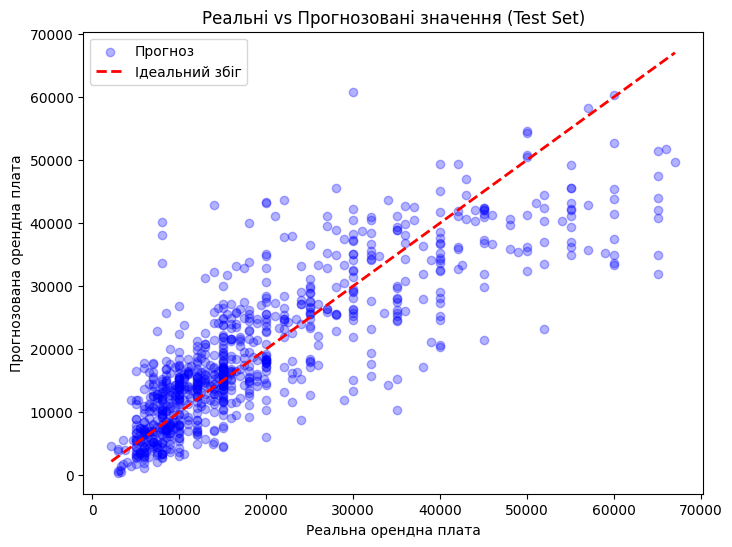

In [35]:
# 4. Графік розсіювання "реальні vs прогнозовані значення"
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, color='blue', label='Прогноз')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Ідеальний збіг')
plt.xlabel('Реальна орендна плата')
plt.ylabel('Прогнозована орендна плата')
plt.title('Реальні vs Прогнозовані значення (Test Set)')
plt.legend()
plt.show()

Аналіз графіка розсіювання підтверджує, що модель успішно вловлює загальні ринкові тенденції, оскільки більшість прогнозів зосереджені вздовж лінії ідеального збігу, що свідчить про надійність та стабільність якості прогнозування.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

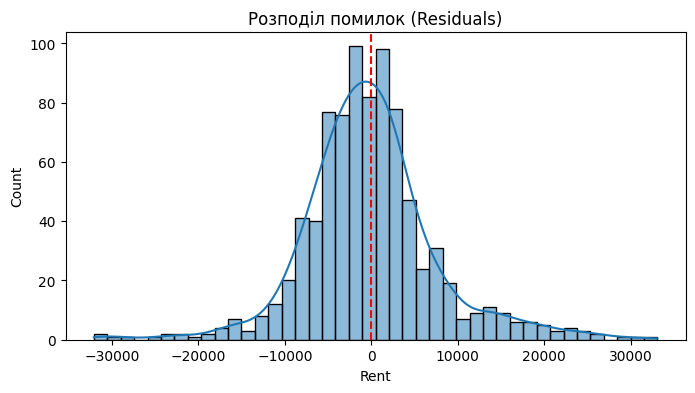

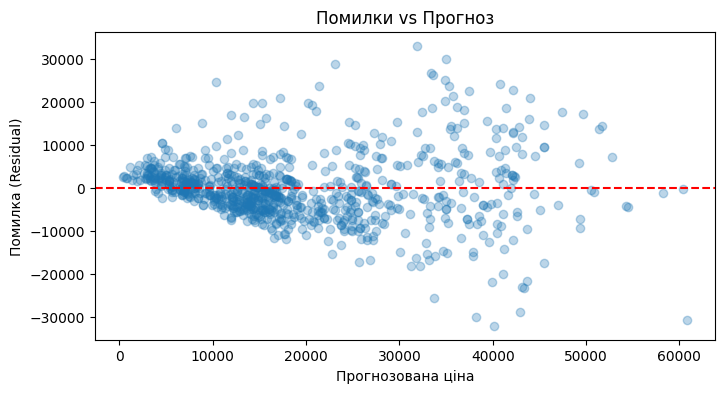

In [37]:
# 1. Обчислюємо помилки
residuals = y_test - y_test_pred

# 2. Гістограма розподілу помилок
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Розподіл помилок (Residuals)')
plt.show()

# 3. Scatter plot помилок відносно прогнозу
plt.figure(figsize=(8, 4))
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Прогнозована ціна')
plt.ylabel('Помилка (Residual)')
plt.title('Помилки vs Прогноз')
plt.show()

In [38]:
# 4. Створюємо DataFrame з помилками
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_test_pred
results_df['Error'] = (y_test - y_test_pred).abs()

# Виводимо 5 прогнозів з найбільшою абсолютною помилкою
print(results_df.sort_values(by='Error', ascending=False).head(5)[['Actual', 'Predicted', 'Error']])

      Actual     Predicted         Error
3962   65000  31911.852185  33088.147815
549     8000  40096.083892  32096.083892
275    30000  60767.243841  30767.243841
904     8000  38173.654972  30173.654972
3520   65000  34974.963125  30025.036875


In [39]:
error_analysis = results_df.groupby(['BHK'])['Error'].mean().sort_values(ascending=False)

print("Середня помилка за кількістю кімнат (BHK):")
print(error_analysis)

Середня помилка за кількістю кімнат (BHK):
BHK
4    12307.449414
3     7883.034834
2     4970.652281
5     4538.016206
1     4328.192506
6     3795.282868
Name: Error, dtype: float64


Згідно з аналізом середньої абсолютної помилки за кількістю кімнат, найбільші відхилення спостерігаються у 4-кімнатних квартирах. Це вказує на те, що лінійна модель недостатньо ефективно моделює ціноутворення у сегменті великого житла, де ціна залежить від складніших, нелінійних факторів (наприклад, престижність району або оздоблення), які не враховані у поточних ознаках. 
Для підвищення точності прогнозування та зменшення помилки для великих об'єктів можна зробити логарифмування цільової змінної так як це дозволить зменшити вплив викидів та збалансувати вплив цінових категорій, переходячи від прогнозування абсолютних значень до відносних.